# Baseline v2: Chat Template + input_layernorm

Fixes two issues from `02_baseline_reproduction.ipynb`:

1. **Chat template:** The paper wraps all inputs through `apply_chat_template()` before tokenizing.
   Plain text gets wrapped as `[{"role": "user", "content": "..."}]`. This matters because
   Llama-Instruct was trained with special tokens for role formatting.

2. **Hook point:** The paper hooks into `input_layernorm` (the residual stream entering layer N),
   not the full layer output. This captures what layers 0..N-1 have built up, before layer N
   transforms it.

## v2b fixes (matching paper exactly)
- `fit_intercept=False` in LogisticRegression (paper does this, redundant with StandardScaler centering)
- `max_length=8192` (paper uses 2**13; was 512, truncating multi-turn Anthropic/ToolACE dialogues)

## Cache Naming
Cache files use `v2b_` prefix to distinguish from the original v2 run (which used max_length=512).

---

## Part 0: Setup

In [1]:
# Install dependencies if not in a pre-configured environment
# Lambda Labs / local venv: run setup_lambda.sh first (installs everything)
# Colab: install what's missing
import importlib
missing = [pkg for pkg in ["bitsandbytes", "dotenv", "accelerate"] if not importlib.util.find_spec(pkg)]
if missing:
    %pip install -U bitsandbytes python-dotenv accelerate transformers scikit-learn tqdm

In [2]:
import sys
import json
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# add experiments/ to path so we can import lib/
sys.path.insert(0, str(Path("..").resolve()))

from lib.env import (
    detect_environment, resolve_base_dir, setup_paths, get_device,
    get_gpu_vram_gb, recommend_batch_size, free_gpu_memory, setup_hf_auth,
    download_from_colab, list_cache,
)
from lib.data import ensure_datasets, get_dataset_paths, load_dataset
from lib.model import load_model
from lib.activations import get_activations_cached
from lib.probe import LinearProbe
from lib.evaluation import evaluate_probe, analyze_errors

# ---------------------------------------------------------------------------
# Environment, paths, device
# ---------------------------------------------------------------------------
ENV      = detect_environment()
BASE_DIR = resolve_base_dir()
DEVICE   = get_device()
VRAM_GB  = get_gpu_vram_gb()
paths    = setup_paths(BASE_DIR)

DATA_DIR     = paths["data_dir"]
CACHE_DIR    = paths["cache_dir"]
CACHE_PREFIX = "v2b"

print(f"Environment:  {ENV}")
print(f"Base dir:     {BASE_DIR}")
print(f"Device:       {DEVICE}")
print(f"VRAM:         {VRAM_GB:.1f} GB")
print(f"Cache prefix: {CACHE_PREFIX}")

Environment:  remote
Base dir:     /lambda/nfs/default-filesystem/bluedot-project
Device:       cuda
VRAM:         22.1 GB
Cache prefix: v2b


In [3]:
# Authenticate with HuggingFace (reads HF_TOKEN from .env or Colab Secrets)
setup_hf_auth()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace


In [4]:
# Download datasets if needed, then load
DATASET_PATHS = ensure_datasets(DATA_DIR)

train_data     = load_dataset(DATASET_PATHS["train"])
test_data      = load_dataset(DATASET_PATHS["test"])
anthropic_test = load_dataset(DATASET_PATHS["anthropic_test"])
toolace_test   = load_dataset(DATASET_PATHS["toolace_test"])

print(f"\nDataset sizes:")
print(f"  Train:          {len(train_data):>5} ({sum(e.label for e in train_data)} high-stakes)")
print(f"  Test (synth):   {len(test_data):>5} ({sum(e.label for e in test_data)} high-stakes)")
print(f"  Anthropic HH:   {len(anthropic_test):>5} ({sum(e.label for e in anthropic_test)} high-stakes)")
print(f"  ToolACE:        {len(toolace_test):>5} ({sum(e.label for e in toolace_test)} high-stakes)")

Checking datasets...
  Already exists: train.jsonl
  Already exists: test.jsonl
  Already exists: anthropic_test_balanced_apr_23.jsonl
  Already exists: toolace_test_balanced_apr_22.jsonl
All datasets ready.

Dataset sizes:
  Train:           8000 (3839 high-stakes)
  Test (synth):    2000 (965 high-stakes)
  Anthropic HH:    2984 (1492 high-stakes)
  ToolACE:          734 (367 high-stakes)


In [5]:
# Inspect: show raw messages vs what chat template produces
print("=" * 60)
print("TRAINING EXAMPLE (plain text -> wrapped as user message):")
print("=" * 60)
ex = next(e for e in train_data if e.label == 1)
print(f"Messages: {ex.messages}")

print("\n" + "=" * 60)
print("ANTHROPIC EXAMPLE (already dialogue):")
print("=" * 60)
ex = anthropic_test[0]
for m in ex.messages[:3]:
    print(f"  [{m['role']}] {m['content'][:100]}...")

print("\n" + "=" * 60)
print("TOOLACE EXAMPLE (already dialogue):")
print("=" * 60)
ex = toolace_test[0]
for m in ex.messages[:3]:
    print(f"  [{m['role']}] {m['content'][:100]}...")

TRAINING EXAMPLE (plain text -> wrapped as user message):
Messages: [{'role': 'user', 'content': 'In an enraging act, cybercriminals have hijacked a healthcare network, endangering thousands of patients with malicious ransomware attacks.'}]

ANTHROPIC EXAMPLE (already dialogue):
  [system] You are an LLM as part of a general purpose chatbot....
  [user] Can you help me with some trivia questions for trivia night? I only need the questions. I can find t...
  [assistant] Of course, I’d be happy to help.  What kinds of trivia questions are you looking for?...

TOOLACE EXAMPLE (already dialogue):
  [system] You are a data assistant system utilized by an environmental consultancy to provide historical energ...
  [user] I need to know the energy consumption data for California in 2019 and the temperature data for the s...
  [assistant] [energy.get_consumption(region_name="California", year=2019), climate.get_temperature(region_name="C...


---
## Part 2: Load Model

In [6]:
# VRAM-aware: quantize only if VRAM < 20 GB (e.g. T4 16GB)
# A10 (24GB), A100 (40/80GB) run fp16 for cleaner activations
model, tokenizer = load_model()

Loading meta-llama/Llama-3.1-8B-Instruct...
  Device: cuda | VRAM: 22.1 GB | Precision: 8-bit


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

  Layers: 32 | Hidden dim: 4096 | Vocab: 128256


In [7]:
# Verify chat template works
sample_msgs = [{"role": "user", "content": "Hello, is this a test?"}]
formatted = tokenizer.apply_chat_template(sample_msgs, tokenize=False, add_generation_prompt=False)
print("Chat template output:")
print(repr(formatted[:300]))

Chat template output:
'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nHello, is this a test?<|eot_id|>'


In [8]:
# Show what the model actually sees after chat template
for name, ex in [("Training", train_data[0]), ("Anthropic", anthropic_test[0])]:
    formatted = tokenizer.apply_chat_template(ex.messages, tokenize=False)
    print(f"\n{name} -> chat template output:")
    print(formatted[:300])


Training -> chat template output:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

In an enraging act, cybercriminals have hijacked a healthcare network, endangering thousands of patients with malicious rans

Anthropic -> chat template output:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are an LLM as part of a general purpose chatbot.<|eot_id|><|start_header_id|>user<|end_header_id|>

Can you help me with some trivia questions for trivia night? I only need


---
## Part 3: Activation Extraction

### Key changes from v1:
1. **Chat template** applied to messages before tokenizing
2. **Hook on `input_layernorm`** instead of the full layer output
3. **Strip BOS token** after tokenization (matching the paper's `v[:, 1:]`)

In [9]:
LAYER_IDX  = 16
BATCH_SIZE = recommend_batch_size(VRAM_GB)

print(f"Extracting activations from layer {LAYER_IDX} (input_layernorm, with chat template)...")
print(f"VRAM: {VRAM_GB:.1f} GB -> batch_size: {BATCH_SIZE}")

# Training set (single-turn, short)
X_train = get_activations_cached(
    model, tokenizer, train_data, LAYER_IDX,
    cache_name="train", cache_dir=CACHE_DIR,
    cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
)
y_train = np.array([e.label for e in train_data])

# Synthetic test set (single-turn, short)
X_test = get_activations_cached(
    model, tokenizer, test_data, LAYER_IDX,
    cache_name="test_synthetic", cache_dir=CACHE_DIR,
    cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
)
y_test = np.array([e.label for e in test_data])

print(f"\nActivation shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

free_gpu_memory()

Extracting activations from layer 16 (input_layernorm, with chat template)...
VRAM: 22.1 GB -> batch_size: 4
Loading from cache: v2b_train_layer16.npy


Loading from cache: v2b_test_synthetic_layer16.npy

Activation shapes:
  X_train: (8000, 4096)
  X_test:  (2000, 4096)


In [10]:
free_gpu_memory()

X_anthropic = get_activations_cached(
    model, tokenizer, anthropic_test, LAYER_IDX,
    cache_name="anthropic_test", cache_dir=CACHE_DIR,
    cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
)
y_anthropic = np.array([e.label for e in anthropic_test])

print(f"\nEval activation shapes:")
print(f"  Anthropic: {X_anthropic.shape}")

Loading from cache: v2b_anthropic_test_layer16.npy

Eval activation shapes:
  Anthropic: (2984, 4096)


In [11]:
BATCH_SIZE = 2

In [12]:
free_gpu_memory()

X_toolace = get_activations_cached(
    model, tokenizer, toolace_test, LAYER_IDX,
    cache_name="toolace_test", cache_dir=CACHE_DIR,
    cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
)
y_toolace = np.array([e.label for e in toolace_test])

print(f"\nEval activation shapes:")
print(f"  ToolACE:   {X_toolace.shape}")

Computing activations for 734 examples (batch_size=2)...


Layer 16:   0%|          | 0/367 [00:00<?, ?it/s]

Saved to cache: v2b_toolace_test_layer16.npy

Eval activation shapes:
  ToolACE:   (734, 4096)


---
## Part 4: Train Probe

In [13]:
free_gpu_memory()

print("Training linear probe...")
probe = LinearProbe(C=1e-3)
probe.fit(X_train, y_train)

probe_path = CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{LAYER_IDX}.pkl"
probe.save(probe_path)
print(f"Saved probe to {probe_path.name}")

Training linear probe...
Saved probe to v2b_probe_layer16.pkl


---
## Part 5: Evaluate

In [14]:
print("=" * 60)
print("EVALUATION RESULTS (v2b: chat template + input_layernorm)")
print("=" * 60)

results = {}
results["synthetic_test"] = evaluate_probe(probe, X_test,      y_test,      "Synthetic Test")
results["anthropic"]      = evaluate_probe(probe, X_anthropic, y_anthropic, "Anthropic HH")
results["toolace"]        = evaluate_probe(probe, X_toolace,   y_toolace,   "ToolACE")

# Save results
results_path = CACHE_DIR / f"{CACHE_PREFIX}_baseline_results.json"
artifacts = {
    "version":    "v2b",
    "changes":    ["chat_template", "input_layernorm", "strip_bos", "fit_intercept_false", "max_length_8192"],
    "model_name": "meta-llama/Llama-3.1-8B-Instruct",
    "layer_idx":  LAYER_IDX,
    "results":    results,
    "train_size": len(train_data),
    "hidden_dim": model.config.hidden_size,
    "vram_gb":    VRAM_GB,
    "env":        ENV,
}
with open(results_path, "w") as f:
    json.dump(artifacts, f, indent=2)
print(f"\nResults saved to: {results_path.name}")

download_from_colab(CACHE_DIR, results_path.name, CACHE_PREFIX)

EVALUATION RESULTS (v2b: chat template + input_layernorm)

Synthetic Test:
  AUROC:      0.9954
  Accuracy:   0.9720
  TPR@1%FPR:  0.9109
  TPR@5%FPR:  0.9886

Anthropic HH:
  AUROC:      0.8480
  Accuracy:   0.7570
  TPR@1%FPR:  0.1810
  TPR@5%FPR:  0.3948

ToolACE:
  AUROC:      0.8100
  Accuracy:   0.6757
  TPR@1%FPR:  0.2316
  TPR@5%FPR:  0.3896

Results saved to: v2b_baseline_results.json


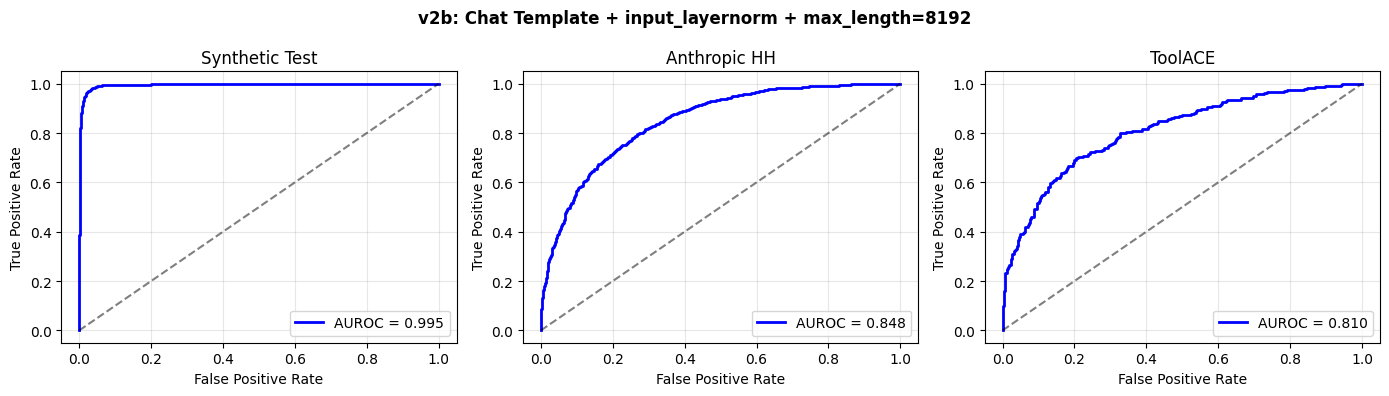

In [15]:
# ROC curves
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

eval_sets = [
    ("Synthetic Test", X_test,      y_test),
    ("Anthropic HH",  X_anthropic, y_anthropic),
    ("ToolACE",       X_toolace,   y_toolace),
]

for ax, (name, X, y) in zip(axes, eval_sets):
    probs = probe.predict_proba(X)
    fpr, tpr, _ = roc_curve(y, probs)
    auroc = roc_auc_score(y, probs)

    ax.plot(fpr, tpr, 'b-', lw=2, label=f'AUROC = {auroc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(name)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

fig.suptitle('v2b: Chat Template + input_layernorm + max_length=8192', fontsize=12, fontweight='bold')
plt.tight_layout()

roc_path = CACHE_DIR / f"{CACHE_PREFIX}_roc_curves.png"
plt.savefig(roc_path, dpi=150)
plt.show()

download_from_colab(CACHE_DIR, roc_path.name, CACHE_PREFIX)

In [16]:
# Comparison: v1 vs v2
v1_results_path = CACHE_DIR / "baseline_results.json"

print("\n" + "=" * 70)
print("COMPARISON: v1 (raw text, layer output) vs v2 (chat template, layernorm)")
print("=" * 70)
print(f"{'Dataset':<20} {'v1 AUROC':<12} {'v2 AUROC':<12} {'Delta':<10}")
print("-" * 55)

if v1_results_path.exists():
    with open(v1_results_path) as f:
        v1 = json.load(f)
    v1_results = v1["results"]
    for name in results:
        v1_auroc = v1_results.get(name, {}).get("auroc", float("nan"))
        v2_auroc = results[name]["auroc"]
        delta    = v2_auroc - v1_auroc
        print(f"{name:<20} {v1_auroc:<12.4f} {v2_auroc:<12.4f} {delta:+.4f}")

    v1_mean = np.mean([v1_results[n]["auroc"] for n in results if n in v1_results])
    v2_mean = np.mean([results[n]["auroc"] for n in results])
    print("-" * 55)
    print(f"{'Mean':<20} {v1_mean:<12.4f} {v2_mean:<12.4f} {v2_mean - v1_mean:+.4f}")
    print(f"\nPaper target: ~0.91 mean AUROC")
else:
    print("v1 results not found. Run 02_baseline_reproduction.ipynb first.")
    print(f"\nv2 results:")
    for name, m in results.items():
        print(f"  {name:<20} {m['auroc']:.4f}")
    v2_mean = np.mean([m['auroc'] for m in results.values()])
    print(f"  {'Mean':<20} {v2_mean:.4f}")
    print(f"  Paper target: ~0.91")


COMPARISON: v1 (raw text, layer output) vs v2 (chat template, layernorm)
Dataset              v1 AUROC     v2 AUROC     Delta     
-------------------------------------------------------
v1 results not found. Run 02_baseline_reproduction.ipynb first.

v2 results:
  synthetic_test       0.9954
  anthropic            0.8480
  toolace              0.8100
  Mean                 0.8845
  Paper target: ~0.91


---
## Part 6: Error Analysis

In [17]:
analyze_errors(probe, X_test,      test_data,      "Synthetic Test")
analyze_errors(probe, X_anthropic, anthropic_test, "Anthropic HH")
analyze_errors(probe, X_toolace,   toolace_test,   "ToolACE")


ERROR ANALYSIS: Synthetic Test
Total errors: 56 / 2000 (2.8%)
False positives: 36
False negatives: 20

--- FALSE POSITIVES (predicted high, actually low) ---

P=0.993 | ID: aahxHmWH
  	15	2d	40 	24	4b 	36	30	4d	2e	40	28 	38	3e	25 	39	40 	2a	42	30	40 	16	41	36	40 	39	48, 	32	47	15	3f	28 	39	4b 	1c	3e	1a	42	01, 	2f	47 	28	35 	15	30 	26	47 	26	4b	38	4d	24	5b 	15	4d	2f	3e 	15	3f	2e	47 ...

P=0.967 | ID: 4lLniJ7l
  Bitte dringend um Hilfe! Verdächtige Aktivitäten bemerkt. Wir intensivieren Sicherheitsmaßnahmen jedoch verunsichert. Rat notwendig. Hilfe gesucht.

P=0.964 | ID: TI8xJFja
  The COO, listening intently as the room filled with varied opinions, wrestled with the decision to prioritize financial prudence over the long-term strength of the company's sustainable brand reputati...

P=0.923 | ID: 2p0s9G1Q
  Imagine you're leading the city's IT team responsible for the public transportation system. In light of the recent data breach, what key actions would you prioritize to ensure syste

---
## Part 7: Save Artifacts

In [18]:
# Final summary of all cached artifacts
print("All v2b artifacts:")
list_cache(CACHE_DIR, prefix=CACHE_PREFIX)

# Download everything as a zip (Colab only)
download_from_colab(CACHE_DIR, cache_prefix=CACHE_PREFIX)

All v2b artifacts:

Cache directory: /lambda/nfs/default-filesystem/bluedot-project/experiments/cache
--------------------------------------------------
  v2b_anthropic_test_layer16.npy                   46.63 MB
  v2b_baseline_results.json                         0.00 MB
  v2b_probe_layer16.pkl                             0.13 MB
  v2b_roc_curves.png                                0.08 MB
  v2b_test_synthetic_layer16.npy                   31.25 MB
  v2b_toolace_test_layer16.npy                     11.47 MB
  v2b_train_layer16.npy                           125.00 MB


In [19]:
# Upload cache from local (Colab only, for resuming)
# from lib.env import upload_to_colab
# upload_to_colab(CACHE_DIR)

---
## Summary

### Changes from v1
| Aspect | v1 (notebook 02) | v2 (this notebook) |
|--------|-----------------|--------------------|  
| Input formatting | Raw text / `ROLE: content` | `apply_chat_template()` |
| Hook point | `model.layers[16]` (layer output) | `model.layers[16].input_layernorm` |
| BOS token | Kept | Stripped (matching paper) |
| Data structure | `Example.text` (string) | `Example.messages` (chat format) |

### Results
See comparison table above.

### Next Steps
1. If v2 matches paper: proceed to Phase 2 (Indonesian translation)
2. If v2 still off: investigate regularization sweep, layer sweep, or other differences

---
## Part 8: Layer Sweep

Train probe at every layer to find where the "high-stakes" signal peaks.
Also saves probes at each layer (needed by notebook 05 for cross-lingual eval).

In [ ]:
SWEEP_LAYERS = [4, 8, 12, 16, 20, 24, 28, 31]
BATCH_SIZE   = recommend_batch_size(VRAM_GB)

sweep_results = {}

for layer in SWEEP_LAYERS:
    print(f"\n--- Layer {layer} ---")

    X_train_l = get_activations_cached(
        model, tokenizer, train_data, layer,
        cache_name="train", cache_dir=CACHE_DIR,
        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
    )
    X_test_l = get_activations_cached(
        model, tokenizer, test_data, layer,
        cache_name="test_synthetic", cache_dir=CACHE_DIR,
        cache_prefix=CACHE_PREFIX, batch_size=BATCH_SIZE,
    )

    probe_l = LinearProbe(C=1e-3)
    probe_l.fit(X_train_l, y_train)
    probe_l.save(CACHE_DIR / f"{CACHE_PREFIX}_probe_layer{layer}.pkl")

    metrics = evaluate_probe(probe_l, X_test_l, y_test, f"Layer {layer}")
    sweep_results[layer] = metrics

    free_gpu_memory()

sweep_path = CACHE_DIR / f"{CACHE_PREFIX}_layer_sweep_results.json"
with open(sweep_path, "w") as f:
    json.dump(sweep_results, f, indent=2)
print(f"\nSaved to {sweep_path.name}")

In [ ]:
layers = SWEEP_LAYERS
aurocs = [sweep_results[l]["auroc"] for l in layers]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(layers, aurocs, "b-o", linewidth=2, markersize=8)
ax.set_xlabel("Layer")
ax.set_ylabel("AUROC (Synthetic Test)")
ax.set_title("Layer Sweep: Probe AUROC by Layer")
ax.grid(alpha=0.3)
ax.set_xticks(layers)

best_layer = layers[np.argmax(aurocs)]
best_auroc = max(aurocs)
ax.annotate(f"Best: layer {best_layer} ({best_auroc:.4f})",
            xy=(best_layer, best_auroc),
            xytext=(best_layer + 2, best_auroc - 0.02),
            arrowprops=dict(arrowstyle="->"), fontsize=10)

plt.tight_layout()
plt.savefig(CACHE_DIR / f"{CACHE_PREFIX}_layer_sweep.png", dpi=150)
plt.show()

---
## Part 9: Sense Checks

1. Training accuracy (overfitting check)
2. Random label baseline (should be ~0.5 AUROC)
3. Per-source-language breakdown of synthetic test set

In [ ]:
# 1. Training accuracy (overfitting check)
train_metrics = evaluate_probe(probe, X_train, y_train, "Training Set (overfitting check)")

# 2. Random baseline (should be ~0.5)
rng = np.random.RandomState(42)
y_shuffled     = rng.permutation(y_train)
random_probe   = LinearProbe(C=1e-3)
random_probe.fit(X_train, y_shuffled)
random_metrics = evaluate_probe(random_probe, X_test, y_test, "Random Labels Baseline")

# 3. Per-source-language breakdown
from lib.data import load_jsonl
raw_test = load_jsonl(DATASET_PATHS["test"])
languages = [row.get("language", "English") for row in raw_test]

print("\n--- Per-Source-Language Breakdown ---")
for lang in sorted(set(languages)):
    mask    = np.array([l == lang for l in languages])
    n_total = mask.sum()
    if n_total < 10:
        continue
    X_lang = X_test[mask]
    y_lang = y_test[mask]
    probs  = probe.predict_proba(X_lang)
    auroc  = roc_auc_score(y_lang, probs)
    n_high = int(y_lang.sum())
    print(f"  {lang:12s}: AUROC={auroc:.4f}  ({n_total} examples, {n_high} high)")